# 29 April 2026
- checking full galaxy sample of CVs
- converting to blip readable format

In [7]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths

In [ ]:
def convert_popsynth_to_blipreadable(input_name, output_name):
    file = paths.lssdata / input_name
    binaries = pd.read_csv(file)
    blip_columns = ['f','h','lat','long']
    xG, yG, zG = binaries[' x_galcent[kpc]'].to_numpy(), binaries[' y_galcent[kpc]'].to_numpy(), binaries[' z_galcent[kpc]'].to_numpy()
    ## convert to distances and lat/long ecliptic coords
    gc = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
    SSBc = gc.transform_to(cc.BarycentricMeanEcliptic)

    ## get latitude, longitude
    lat = SSBc.lat.to(u.rad).value
    long = SSBc.lon.to(u.rad).value

    ## making sure we've handled our coordinate transforms correctly
    dist = SSBc.distance.to(u.kpc)
    mc = lw.utils.chirp_mass(binaries['# m1[Msun]'],binaries[' m2[Msun]']).to_numpy()*u.Msun
    fs = binaries[' f_gw[Hz]'].to_numpy()
    f_orb = fs*u.Hz/2
    ## assuming circular binaries
    ecc = np.zeros(len(f_orb))

    hs = lw.strain.h_0_n(mc,f_orb,ecc,2,dist)

    blip_df = pd.DataFrame(data=np.vstack((fs,hs.flatten(),lat,long)).T,columns=blip_columns)

    blip_df.to_csv(paths.lssdata/output_name, index=False,sep=' ',header=False)


In [11]:
cvgxyfile = paths.lssdata / 'dat_fullgxy_rs42_final.txt'
cvgxy = pd.read_csv(cvgxyfile)
print(cvgxy.columns)


Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]',
       ' Pala_reassigned'],
      dtype='object')


In [12]:
cvgxy

,# m1[Msun],m2[Msun],f_gw[Hz],inclination[rad],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],Pala_reassigned
0,0.699697,0.215751,0.000166,1.321845,18.028572,-1.642931,0.461144,0.0
1,0.700623,0.040137,0.000420,0.858970,9.279758,17.196646,0.006690,0.0
2,0.699254,0.130330,0.000303,2.234177,3.946339,13.842370,-0.366433,0.0
3,0.699063,0.141270,0.000289,0.529390,-13.759254,-13.555558,0.067144,0.0
4,0.700365,0.115352,0.000326,0.925816,-13.760219,-4.056018,0.529109,0.0
...,...,...,...,...,...,...,...,...
3376534,0.702507,0.145504,0.000284,0.976051,-1.622053,-0.761233,0.420823,0.0
3376535,0.699574,0.656339,0.000092,1.202286,17.163478,-9.222644,-0.290653,0.0
3376536,0.700861,0.199081,0.000175,0.431507,10.006158,-9.761735,0.131880,0.0
3376537,0.699792,0.098910,0.000350,1.672847,15.055509,3.399866,0.234033,0.0


In [18]:
input_name = 'dat_fullgxy_rs42_final.txt'
output_name = input_name.split('.')[0]+'_blip.txt'
convert_popsynth_to_blipreadable(input_name, output_name)

Index(['# m1[Msun]', ' m2[Msun]', ' f_gw[Hz]', ' inclination[rad]',
       ' x_galcent[kpc]', ' y_galcent[kpc]', ' z_galcent[kpc]',
       ' Pala_reassigned'],
      dtype='object')


(array([ 3333.,  3397.,  3561.,  3662.,  3850.,  4014.,  4011.,  4108.,
         4100.,  4255.,  4391.,  4397.,  4627.,  4627.,  4570.,  4700.,
         4694.,  4809.,  4858.,  5013.,  4988.,  5091.,  5140.,  5294.,
         5273.,  5481.,  5390.,  5436.,  5536.,  5477.,  5697.,  5768.,
         5718.,  5824.,  5876.,  5852.,  5817.,  6019.,  6042.,  6013.,
         6064.,  6132.,  6182.,  6310.,  6330.,  6302.,  6387.,  6501.,
         6490.,  6497.,  6563.,  6717.,  6647.,  6868.,  6916.,  6831.,
         6901.,  6996.,  7037.,  6996.,  7024.,  7002.,  7092.,  7182.,
         7257.,  7458.,  7393.,  7510.,  7384.,  7728.,  7718.,  7765.,
         7768.,  7984.,  8110.,  8137.,  8346.,  8459.,  8632.,  8906.,
         9130.,  9235.,  9685., 10016., 10637., 11864., 15161.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0., 

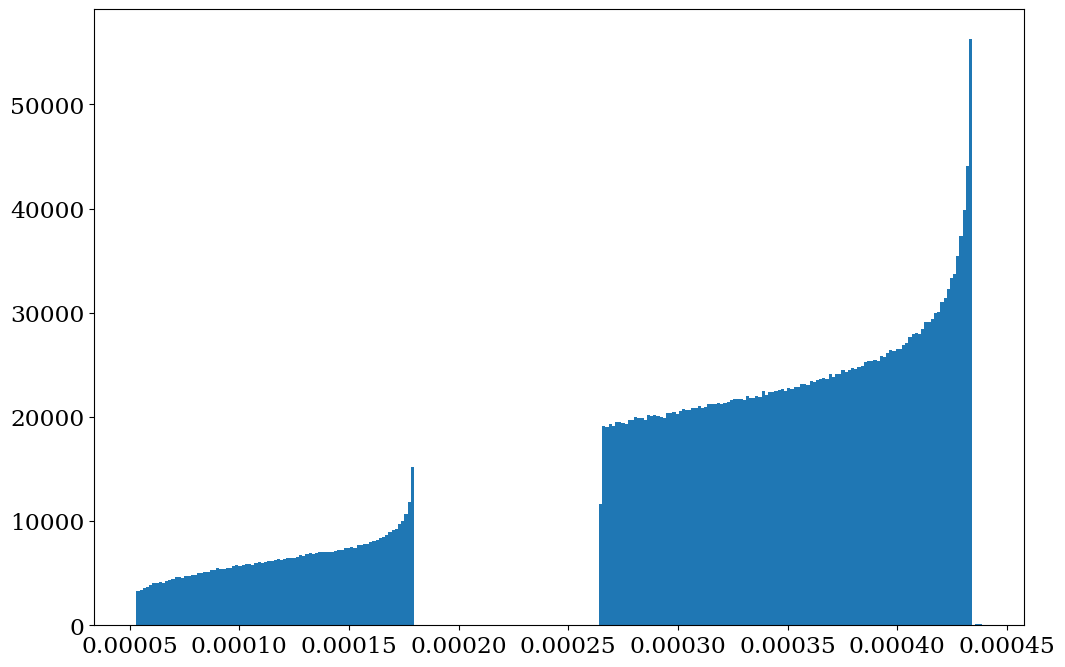

In [21]:
plt.hist(cvgxy[' f_gw[Hz]'], bins='auto')

In [25]:
c_galcent = cc.SkyCoord(x=cvgxy[' x_galcent[kpc]'].values*u.kpc,y=cvgxy[' y_galcent[kpc]'].values*u.kpc,z=cvgxy[' z_galcent[kpc]'].values*u.kpc, frame='galactocentric', representation_type='cartesian')
c_ecl = c_galcent.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat = c_ecl.lat.to(u.rad).value
long = c_ecl.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

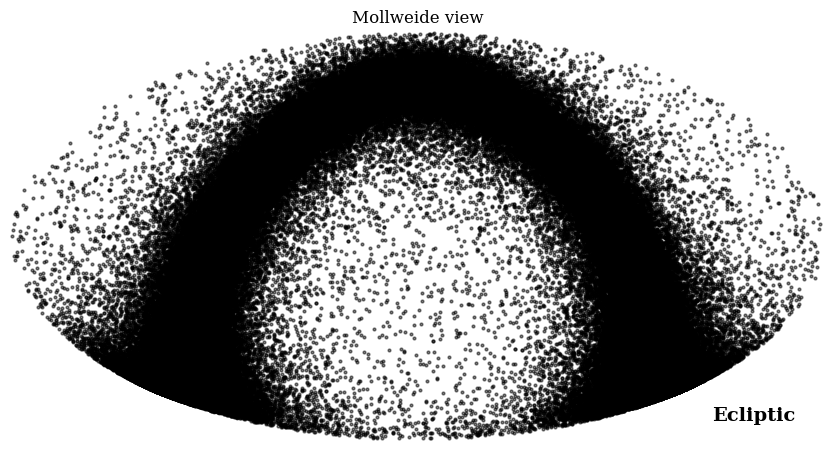

In [26]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()